In [5]:
import clickhouse_connect
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Connect to ClickHouse ---
client = clickhouse_connect.get_client(
    host='192.168.88.253',  # change as needed
    port=8123,
    username='default',  # or your username
    password='uf80Zfvt7XWORQtn',     
)


In [6]:
import numpy as np

In [40]:
#### import matplotlib.dates as mdates

window_size = 100
query = """
SELECT
    toTimezone(dt, 'Europe/Moscow') AS dt,
    toInt64(data.snakes_lengths.adam) AS adam_length,
    toInt64(data.episode) AS episode,
    experiment_name,
    deploy_dt,
    -- Extract maxStepsWithoutFood from experiment name
    toInt32(extractGroups(experiment_name, 'game_over_maxsteps(\\d+)_')[1]) AS max_steps_without_food,
    -- Extract beta from experiment name
    CASE 
        WHEN experiment_name LIKE '%beta0_lr%' THEN 0
        WHEN experiment_name LIKE '%beta0_0001_lr%' THEN 0.0001
        WHEN experiment_name LIKE '%beta0_16_lr%' THEN 0.16
        ELSE NULL
    END AS beta,
    avg(toInt64(adam_length)) 
        OVER (PARTITION BY deploy_dt ORDER BY toInt64(data.episode) ASC ROWS BETWEEN 200 PRECEDING AND CURRENT ROW) AS rolling_avg
FROM raw.rl_snake_logs
PREWHERE toTimezone(deploy_dt,'Europe/Moscow') >= '2025-09-05 09:42:00' and event REGEXP 'game_over_res'
    AND experiment_name REGEXP '^game_over_maxsteps\\d+_beta.*'
ORDER BY max_steps_without_food, beta, episode

"""

df = client.query_df(query)


df




,dt,container,event,data
0,2025-09-06 13:28:30.131853+03:00,inference,state_received,"{'delay_s': '0.0004546642303466797', 'episode'..."
1,2025-09-06 13:28:30.120780+03:00,inference,state_received,"{'delay_s': '0.0004756450653076172', 'episode'..."
2,2025-09-06 13:28:30.109793+03:00,inference,state_received,"{'delay_s': '0.0004398822784423828', 'episode'..."
3,2025-09-06 13:28:30.098836+03:00,inference,state_received,"{'delay_s': '0.0004405975341796875', 'episode'..."
4,2025-09-06 13:28:30.087881+03:00,inference,state_received,"{'delay_s': '0.00044083595275878906', 'episode..."
...,...,...,...,...
528572,2025-09-06 11:28:47.036206+03:00,inference,state_received,"{'delay_s': '0.00036787986755371094', 'episode..."
528573,2025-09-06 11:28:47.016237+03:00,inference,state_received,"{'delay_s': '0.002031564712524414', 'episode':..."
528574,2025-09-06 11:28:46.995720+03:00,inference,state_received,"{'delay_s': '0.010637760162353516', 'episode':..."
528575,2025-09-06 11:28:46.963825+03:00,inference,state_received,"{'delay_s': '0.001306295394897461', 'episode':..."


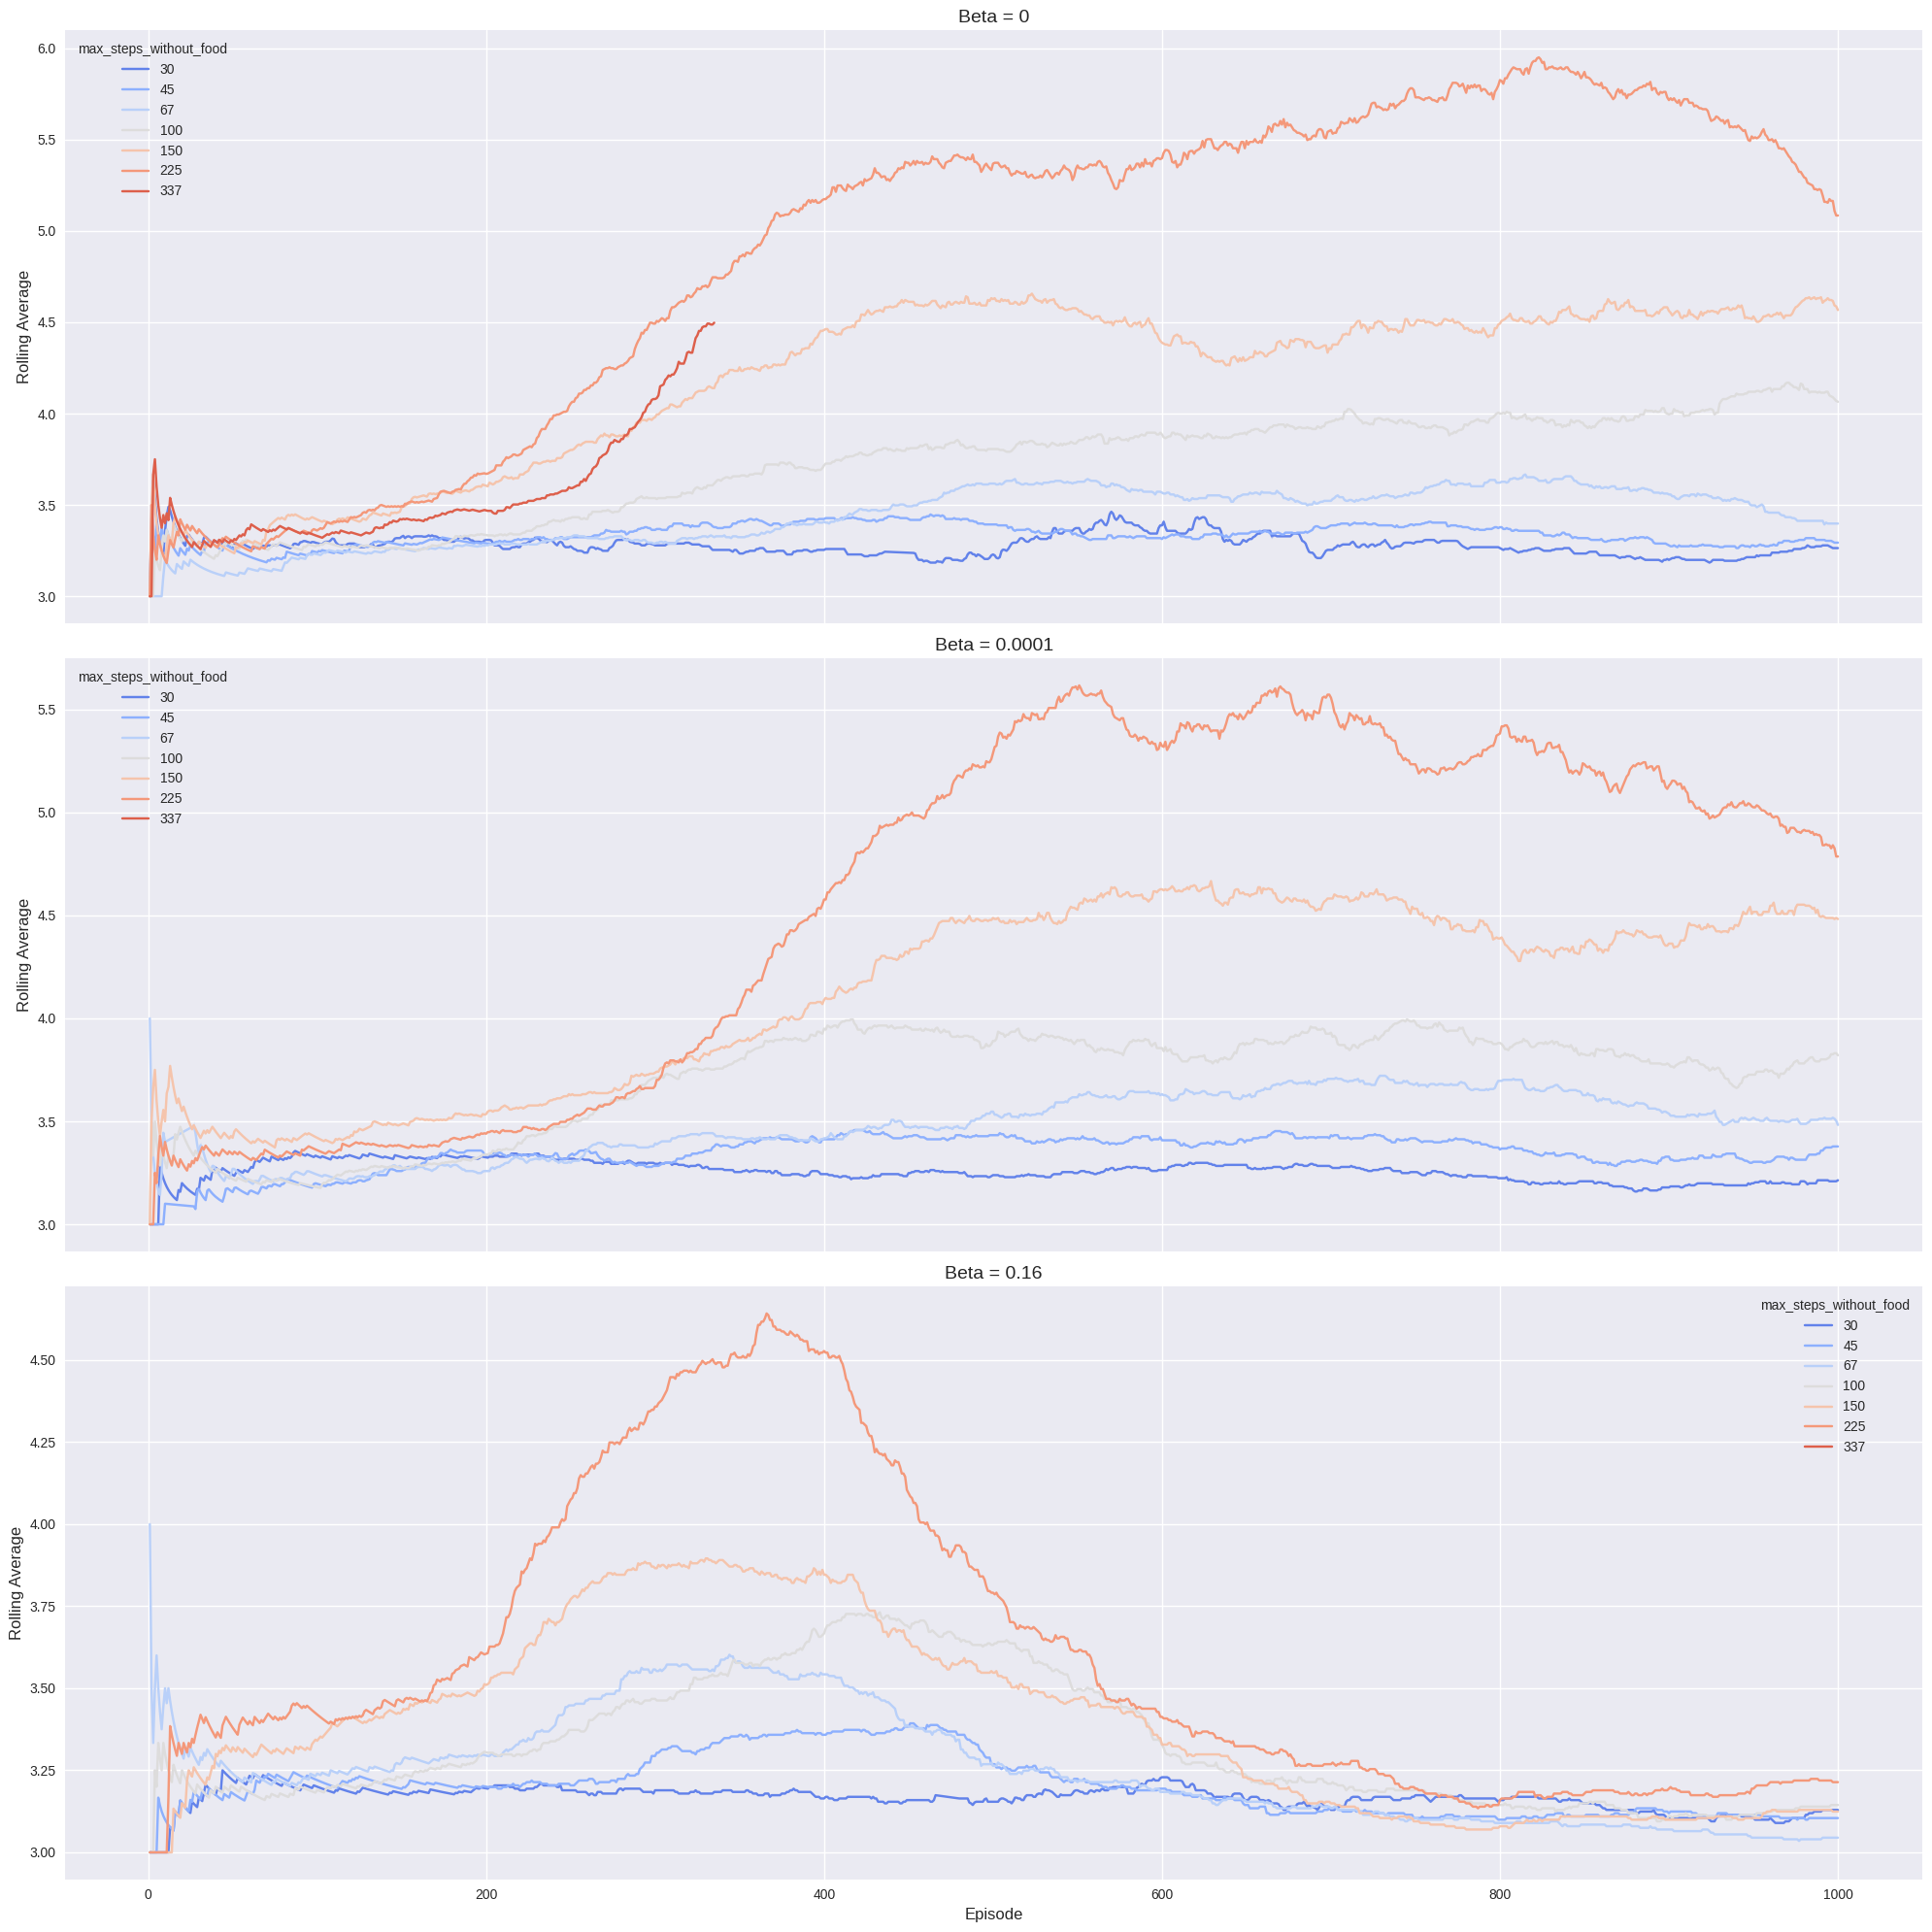

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
hue_order = df['max_steps_without_food'].sort_values().unique().astype(str)
df['max_steps_without_food'] = df['max_steps_without_food'].astype(str)
# Create figure with two subplots sharing x-axis
fig, (ax1, ax2,ax3) = plt.subplots(3, 1, figsize=(20, 20), sharex=True)

# Filter data for beta = 0
beta_0_data = df[df['beta'] == 0]

# Filter data for beta = 0.001
beta_001_data = df[df['beta'] == 0.0001]

beta_016_data = df[df['beta'] == 0.16]
# Sort by max_steps_without_food to ensure coldest to warmest color progression
beta_0_data = beta_0_data.sort_values('max_steps_without_food')
beta_001_data = beta_001_data.sort_values('max_steps_without_food')
beta_016_data = beta_016_data.sort_values('max_steps_without_food')

# Plot for beta = 0
sns.lineplot(data=beta_0_data, 
             x='episode', 
             y='rolling_avg',
             hue='max_steps_without_food',
             hue_order=hue_order,
             ax=ax1,
             palette='coolwarm')
ax1.set_title('Beta = 0', fontsize=14)
ax1.set_xlabel('')
ax1.set_ylabel('Rolling Average', fontsize=12)

# Plot for beta = 0.001
sns.lineplot(data=beta_001_data, 
             x='episode', 
             y='rolling_avg',
             hue='max_steps_without_food',
             hue_order=hue_order,
             ax=ax2,
             palette='coolwarm')
ax2.set_title('Beta = 0.0001', fontsize=14)
ax2.set_xlabel('Episode', fontsize=12)
ax2.set_ylabel('Rolling Average', fontsize=12)


# Plot for beta = 0.16
sns.lineplot(data=beta_016_data, 
             x='episode', 
             y='rolling_avg',
             hue='max_steps_without_food',
             hue_order=hue_order,
             ax=ax3,
             palette='coolwarm')
ax3.set_title('Beta = 0.16', fontsize=14)
ax3.set_xlabel('Episode', fontsize=12)
ax3.set_ylabel('Rolling Average', fontsize=12)


# Adjust layout and show
plt.tight_layout()
plt.show()

In [25]:
df[df['beta'].isna()]

,dt,adam_length,episode,experiment_name,deploy_dt,max_steps_without_food,beta,rolling_avg
